In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv("../data/processed/master_dataset.csv")

print(df.shape)
df.head()

(2693087, 12)


,session_id,timestamp,coolant_temp,map,rpm,speed,iat,maf,throttle_pos,ambient_temp,pedal_d,pedal_e
0,2017-07-05_Seat_Leon_RT_S_Stau,0.813,31.0,96.0,0.0,0.0,22.0,0.91,89.0,21.0,14.1,14.5
1,2017-07-05_Seat_Leon_RT_S_Stau,0.901,31.0,96.0,0.0,0.0,22.0,0.91,89.0,21.0,14.1,14.5
2,2017-07-05_Seat_Leon_RT_S_Stau,0.991,31.0,96.0,0.0,0.0,22.0,0.91,89.0,21.0,14.1,14.5
3,2017-07-05_Seat_Leon_RT_S_Stau,1.081,31.0,96.0,0.0,0.0,22.0,0.91,89.0,21.0,14.1,14.5
4,2017-07-05_Seat_Leon_RT_S_Stau,1.171,31.0,96.0,0.0,0.0,22.0,0.91,89.0,21.0,14.1,14.5


In [4]:
df["speed_delta"] = (
    df.groupby("session_id")["speed"]
      .diff()
)

df["rpm_delta"] = (
    df.groupby("session_id")["rpm"]
      .diff()
)

df["maf_delta"] = (
    df.groupby("session_id")["maf"]
      .diff()
)

df["map_delta"] = (
    df.groupby("session_id")["map"]
      .diff()
)

df["throttle_delta"] = (
    df.groupby("session_id")["throttle_pos"]
      .diff()
)

In [5]:
FEATURES = [
    "rpm",
    "speed",
    "maf",
    "map",
    "throttle_pos",
    "rpm_delta",
    "speed_delta",
    "maf_delta",
    "map_delta",
    "throttle_delta",
]

X = df[FEATURES].fillna(0)

print(X.shape)

(2693087, 10)


In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(2693087, 10)


In [7]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(2693087, 10)


In [8]:
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[0.32407087 0.11567757 0.10105938 0.10039934 0.10007883 0.09986005
 0.0862455  0.04438039 0.01921066 0.0090174 ]


In [9]:
cumulative_variance = np.cumsum(
    explained_variance
)

print(cumulative_variance)

[0.32407087 0.43974844 0.54080783 0.64120717 0.741286   0.84114605
 0.92739155 0.97177194 0.9909826  1.        ]


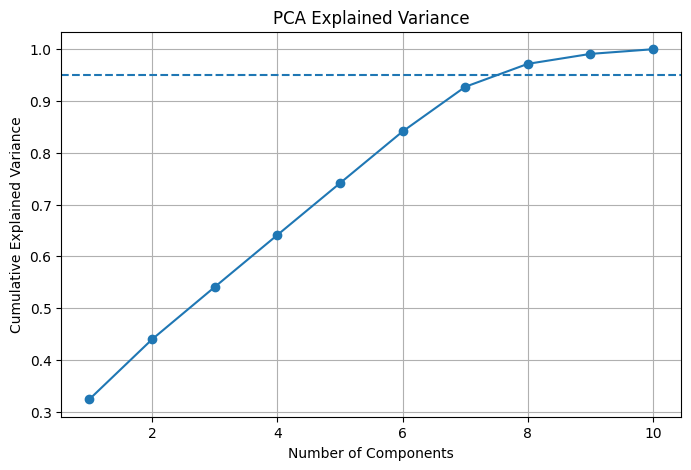

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.95,
    linestyle="--"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

In [11]:
n_components_95 = (
    np.argmax(cumulative_variance >= 0.95)
    + 1
)

print(
    f"Components required for 95% variance: "
    f"{n_components_95}"
)

Components required for 95% variance: 8


In [12]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[
        f"PC{i+1}"
        for i in range(len(FEATURES))
    ],
    index=FEATURES
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
rpm,0.500415,-0.062599,-0.071266,-0.034832,0.011712,-0.010183,-0.051357,-0.446335,-0.612318,-0.402924
speed,0.489322,-0.044155,-0.096237,-0.024750,-0.046743,-0.063170,-0.021859,-0.524985,0.633153,0.256116
maf,0.514735,-0.016387,0.000439,0.057321,0.001453,-0.002816,-0.011112,0.414967,-0.325453,0.673233
map,0.491801,0.106717,0.093302,-0.016100,-0.004246,-0.000419,0.085850,0.559001,0.331518,-0.554981
throttle_pos,0.006244,0.717551,-0.030741,0.000830,-0.000952,-0.003362,0.676229,-0.129912,-0.072114,0.069004
rpm_delta,0.016758,0.308259,-0.005788,-0.472421,0.748698,0.106062,-0.327604,-0.002959,0.024332,0.041926
speed_delta,0.051299,0.055914,0.517155,0.125536,-0.085155,0.829036,-0.054847,-0.110418,0.018301,0.030767
maf_delta,0.014664,0.085552,0.123266,0.838338,0.479956,-0.174351,-0.091382,-0.058550,0.026599,-0.034913
map_delta,0.004786,0.284527,0.705059,-0.126747,-0.251771,-0.496343,-0.295354,-0.077690,-0.039016,0.036216
throttle_delta,-0.011782,0.530256,-0.442971,0.191867,-0.368932,0.143467,-0.571129,0.044210,0.001815,-0.028535


In [13]:
loadings.iloc[:, :5]

,PC1,PC2,PC3,PC4,PC5
rpm,0.500415,-0.062599,-0.071266,-0.034832,0.011712
speed,0.489322,-0.044155,-0.096237,-0.024750,-0.046743
maf,0.514735,-0.016387,0.000439,0.057321,0.001453
map,0.491801,0.106717,0.093302,-0.016100,-0.004246
throttle_pos,0.006244,0.717551,-0.030741,0.000830,-0.000952
rpm_delta,0.016758,0.308259,-0.005788,-0.472421,0.748698
speed_delta,0.051299,0.055914,0.517155,0.125536,-0.085155
maf_delta,0.014664,0.085552,0.123266,0.838338,0.479956
map_delta,0.004786,0.284527,0.705059,-0.126747,-0.251771
throttle_delta,-0.011782,0.530256,-0.442971,0.191867,-0.368932
